# Week 2 — PPO Training and Held-Out Evaluation

This notebook trains a Stable Baselines3 PPO agent on the synthetic Aido Rover patrol environment created in `W02_RL_Environment.ipynb`.

The experiment follows the Week 2 evaluation requirements:

- train PPO for at least 200,000 timesteps;
- set and document the discount factor explicitly;
- log training metrics to TensorBoard;
- produce a training reward curve;
- evaluate on at least 20 held-out episodes;
- compare PPO with random and rule-based baselines;
- produce a sample policy rollout visualization.

The held-out evaluation seeds used below are not used for PPO training or hyperparameter selection.


In [13]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor, load_results
from stable_baselines3.common.results_plotter import ts2xy
from stable_baselines3.common.utils import set_random_seed


## Reproducible experiment configuration

The training seed is fixed at `42`. The PPO discount factor is explicitly set to `0.99`, rather than relying on an implicit default.

The training run uses 200,000 timesteps, which is the lower end of the Week 2 target range for this simpler environment.


In [14]:
SEED = 42

ENV_CONFIG = {
    "max_steps": 200,
    "fault_probability": 0.05,
    "fault_timeout": 8,
}

PPO_CONFIG = {
    "learning_rate": 3e-4,
    "n_steps": 2048,
    "batch_size": 64,
    "n_epochs": 10,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "clip_range": 0.2,
}

TOTAL_TIMESTEPS = 200_000
N_EVAL_EPISODES = 20

BASE_DIR = Path(".")
LOG_DIR = BASE_DIR / "tensorboard_logs"
MODEL_DIR = BASE_DIR / "models"
CONFIG_DIR = BASE_DIR.parent / "configs"

LOG_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
CONFIG_DIR.mkdir(exist_ok=True)

config_to_save = {
    "seed": SEED,
    "environment": ENV_CONFIG,
    "ppo": PPO_CONFIG,
    "total_timesteps": TOTAL_TIMESTEPS,
    "held_out_episodes": N_EVAL_EPISODES,
}

with open(CONFIG_DIR / "W02_ppo_config.json", "w", encoding="utf-8") as f:
    json.dump(config_to_save, f, indent=2)

print("Saved config to:", CONFIG_DIR / "W02_ppo_config.json")


Saved config to: configs\W02_ppo_config.json


## Aido Rover environment

The training notebook uses the same environment design as `W02_RL_Environment.ipynb`.

The observation vector is:

`[motor_current, battery_soc, imu_magnitude, proximity, rssi]`

The four actions are:

- `0 = PATROL`
- `1 = ALERT`
- `2 = CHARGE`
- `3 = INVESTIGATE`


In [15]:
class AidoRoverEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    PATROL = 0
    ALERT = 1
    CHARGE = 2
    INVESTIGATE = 3

    def __init__(
        self,
        max_steps=200,
        fault_probability=0.05,
        fault_timeout=8,
    ):
        super().__init__()

        self.max_steps = max_steps
        self.fault_probability = fault_probability
        self.fault_timeout = fault_timeout

        self.observation_space = spaces.Box(
            low=np.zeros(5, dtype=np.float32),
            high=np.ones(5, dtype=np.float32),
            dtype=np.float32,
        )

        self.action_space = spaces.Discrete(4)

        self.step_count = 0
        self.fault_active = False
        self.fault_age = 0

        self.motor_current = 0.0
        self.battery_soc = 1.0
        self.imu_magnitude = 0.0
        self.proximity = 1.0
        self.rssi = 1.0

    def _get_observation(self):
        return np.array(
            [
                self.motor_current,
                self.battery_soc,
                self.imu_magnitude,
                self.proximity,
                self.rssi,
            ],
            dtype=np.float32,
        )

    def _get_info(self):
        return {
            "fault_active": self.fault_active,
            "fault_age": self.fault_age,
            "step_count": self.step_count,
        }

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.step_count = 0
        self.fault_active = False
        self.fault_age = 0

        self.motor_current = float(self.np_random.uniform(0.20, 0.40))
        self.battery_soc = float(self.np_random.uniform(0.85, 1.00))
        self.imu_magnitude = float(self.np_random.uniform(0.05, 0.20))
        self.proximity = float(self.np_random.uniform(0.60, 1.00))
        self.rssi = float(self.np_random.uniform(0.70, 1.00))

        return self._get_observation(), self._get_info()

    def _update_sensors(self, action):
        if action == self.CHARGE:
            self.battery_soc = min(1.0, self.battery_soc + 0.08)
        elif action == self.INVESTIGATE:
            self.battery_soc = max(0.0, self.battery_soc - 0.015)
        elif action == self.ALERT:
            self.battery_soc = max(0.0, self.battery_soc - 0.006)
        else:
            self.battery_soc = max(0.0, self.battery_soc - 0.010)

        if (
            not self.fault_active
            and self.np_random.random() < self.fault_probability
        ):
            self.fault_active = True
            self.fault_age = 0

        if self.fault_active:
            self.fault_age += 1
            target_motor = 0.80
            target_imu = 0.75
            target_proximity = 0.20
            target_rssi = 0.45
        else:
            self.fault_age = 0
            target_motor = 0.30
            target_imu = 0.15
            target_proximity = 0.80
            target_rssi = 0.85

        self.motor_current = float(
            np.clip(
                0.7 * self.motor_current
                + 0.3 * target_motor
                + self.np_random.normal(0.0, 0.03),
                0.0,
                1.0,
            )
        )

        self.imu_magnitude = float(
            np.clip(
                0.7 * self.imu_magnitude
                + 0.3 * target_imu
                + self.np_random.normal(0.0, 0.03),
                0.0,
                1.0,
            )
        )

        self.proximity = float(
            np.clip(
                0.7 * self.proximity
                + 0.3 * target_proximity
                + self.np_random.normal(0.0, 0.04),
                0.0,
                1.0,
            )
        )

        self.rssi = float(
            np.clip(
                0.7 * self.rssi
                + 0.3 * target_rssi
                + self.np_random.normal(0.0, 0.03),
                0.0,
                1.0,
            )
        )

    def _calculate_reward(self, action):
        reward = 0.0

        if action == self.CHARGE:
            if self.battery_soc < 0.25:
                reward += 3.0
            else:
                reward -= 1.0

        if self.fault_active:
            if action == self.ALERT:
                reward += 5.0
                self.fault_active = False
                self.fault_age = 0

            elif action == self.INVESTIGATE:
                reward += 4.0

                if self.np_random.random() < 0.70:
                    self.fault_active = False
                    self.fault_age = 0

            elif action == self.PATROL:
                reward -= 3.0

            elif action == self.CHARGE:
                reward -= 2.0

        else:
            if action == self.PATROL:
                reward += 1.0
            elif action == self.ALERT:
                reward -= 1.5
            elif action == self.INVESTIGATE:
                reward -= 0.75

        if self.battery_soc <= 0.0:
            reward -= 10.0

        return reward

    def step(self, action):
        if not self.action_space.contains(action):
            raise ValueError(f"Invalid action: {action}")

        self.step_count += 1

        self._update_sensors(action)
        reward = self._calculate_reward(action)

        terminated = False
        truncated = False

        if self.battery_soc <= 0.0:
            terminated = True

        if self.fault_active and self.fault_age > self.fault_timeout:
            reward -= 8.0
            terminated = True

        if self.step_count >= self.max_steps:
            truncated = True

        return (
            self._get_observation(),
            reward,
            terminated,
            truncated,
            self._get_info(),
        )

    def render(self):
        state = "FAULT" if self.fault_active else "NORMAL"

        print(
            f"step={self.step_count:03d} | "
            f"state={state:6s} | "
            f"battery={self.battery_soc:.2f} | "
            f"motor={self.motor_current:.2f} | "
            f"imu={self.imu_magnitude:.2f} | "
            f"proximity={self.proximity:.2f} | "
            f"rssi={self.rssi:.2f}"
        )

    def close(self):
        pass


## TensorBoard callback

Stable Baselines3 PPO already logs the standard PPO metrics used in the internship plan, including episode reward, episode length, value loss, and policy-gradient loss when the environment is wrapped with `Monitor`.

The callback below adds Aido Rover-specific metrics: mean battery state of charge and observed fault rate.


In [16]:
class RoverMetricsCallback(BaseCallback):
    def __init__(self, log_frequency=1000, verbose=0):
        super().__init__(verbose)
        self.log_frequency = log_frequency
        self.battery_values = []
        self.fault_values = []

    def _on_step(self):
        observations = self.locals.get("new_obs")
        infos = self.locals.get("infos", [])

        if observations is not None:
            observations = np.asarray(observations)

            if observations.ndim == 2:
                self.battery_values.extend(observations[:, 1].tolist())
            else:
                self.battery_values.append(float(observations[1]))

        for info in infos:
            self.fault_values.append(float(info.get("fault_active", False)))

        if self.n_calls % self.log_frequency == 0:
            if self.battery_values:
                self.logger.record(
                    "rover/mean_battery_soc",
                    float(np.mean(self.battery_values)),
                )

            if self.fault_values:
                self.logger.record(
                    "rover/fault_rate",
                    float(np.mean(self.fault_values)),
                )

            self.battery_values.clear()
            self.fault_values.clear()

        return True


## PPO training

The environment is wrapped with `Monitor` so episode reward and episode length are logged correctly.

The TensorBoard event files produced by this training run should be kept in the repository together with the notebook.


In [17]:
set_random_seed(SEED)

monitor_file = LOG_DIR / "training_monitor"

train_env = AidoRoverEnv(**ENV_CONFIG)
train_env.reset(seed=SEED)
train_env = Monitor(train_env, filename=str(monitor_file))

model = PPO(
    "MlpPolicy",
    train_env,
    seed=SEED,
    tensorboard_log=str(LOG_DIR),
    verbose=1,
    **PPO_CONFIG,
)

callback = RoverMetricsCallback(log_frequency=1000)

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callback,
    tb_log_name="PPO_AidoRover",
)

model.save(MODEL_DIR / "ppo_aido_rover")
train_env.close()

print("Training complete.")
print("Saved model to:", MODEL_DIR / "ppo_aido_rover.zip")


Using cpu device
Wrapping the env in a DummyVecEnv.
Logging to tensorboard_logs\PPO_AidoRover_2
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 200      |
|    ep_rew_mean      | -86.8    |
| rover/              |          |
|    fault_rate       | 0.066    |
|    mean_battery_soc | 0.966    |
| time/               |          |
|    fps              | 1686     |
|    iterations       | 1        |
|    time_elapsed     | 1        |
|    total_timesteps  | 2048     |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 194         |
|    ep_rew_mean          | -69.2       |
| rover/                  |             |
|    fault_rate           | 0.089       |
|    mean_battery_soc     | 0.941       |
| time/                   |             |
|    fps                  | 1452        |
|    iterations           | 2           |
|    time_elapsed         | 2

## Training reward curve

The reward curve below uses the `Monitor` episode records produced during training.

The main question is whether mean episode reward improves and then stabilizes, indicating that PPO has learned a repeatable policy.


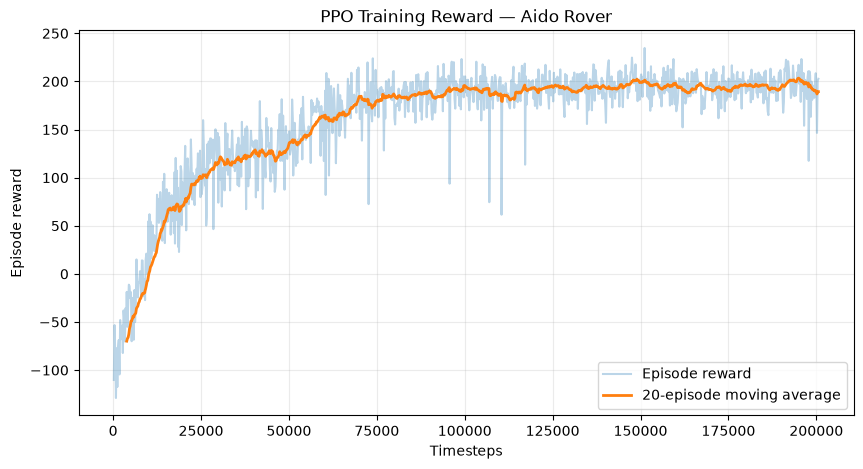

In [18]:
results = load_results(str(LOG_DIR))
timesteps, rewards = ts2xy(results, "timesteps")

window = min(20, len(rewards))

if window > 1:
    smoothed_rewards = np.convolve(
        rewards,
        np.ones(window) / window,
        mode="valid",
    )
    smoothed_timesteps = timesteps[window - 1:]

    plt.figure(figsize=(10, 5))
    plt.plot(timesteps, rewards, alpha=0.30, label="Episode reward")
    plt.plot(
        smoothed_timesteps,
        smoothed_rewards,
        linewidth=2,
        label=f"{window}-episode moving average",
    )
    plt.xlabel("Timesteps")
    plt.ylabel("Episode reward")
    plt.title("PPO Training Reward — Aido Rover")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()
else:
    print("Not enough completed episodes to plot a moving average.")


## Held-out evaluation

The evaluation uses 20 fixed seeds from `10000` through `10019`. These seeds are deliberately separated from the training seed and are not used for training or hyperparameter tuning.

Three policies are compared:

1. **PPO** — the trained policy.
2. **Random baseline** — selects one of the four actions uniformly at random.
3. **Rule-based baseline** — alerts when proximity is below `0.30`, charges when battery SoC is below `0.20`, otherwise patrols.


In [19]:
ACTION_NAMES = {
    AidoRoverEnv.PATROL: "PATROL",
    AidoRoverEnv.ALERT: "ALERT",
    AidoRoverEnv.CHARGE: "CHARGE",
    AidoRoverEnv.INVESTIGATE: "INVESTIGATE",
}


def ppo_policy(observation, env, rng):
    action, _ = model.predict(observation, deterministic=True)
    return int(action)


def random_policy(observation, env, rng):
    return int(rng.integers(env.action_space.n))


def rule_based_policy(observation, env, rng):
    battery_soc = observation[1]
    proximity = observation[3]

    if proximity < 0.30:
        return AidoRoverEnv.ALERT

    if battery_soc < 0.20:
        return AidoRoverEnv.CHARGE

    return AidoRoverEnv.PATROL


def evaluate_policy(policy_fn, seeds):
    episode_rewards = []

    for seed in seeds:
        env = AidoRoverEnv(**ENV_CONFIG)
        observation, info = env.reset(seed=seed)
        rng = np.random.default_rng(seed + 50_000)

        total_reward = 0.0

        while True:
            action = policy_fn(observation, env, rng)

            (
                observation,
                reward,
                terminated,
                truncated,
                info,
            ) = env.step(action)

            total_reward += reward

            if terminated or truncated:
                break

        episode_rewards.append(total_reward)
        env.close()

    return np.asarray(episode_rewards, dtype=float)


In [20]:
held_out_seeds = list(
    range(10_000, 10_000 + N_EVAL_EPISODES)
)

ppo_rewards = evaluate_policy(
    ppo_policy,
    held_out_seeds,
)

random_rewards = evaluate_policy(
    random_policy,
    held_out_seeds,
)

rule_rewards = evaluate_policy(
    rule_based_policy,
    held_out_seeds,
)


def summarize(name, rewards):
    return {
        "policy": name,
        "mean": float(np.mean(rewards)),
        "std": float(np.std(rewards, ddof=1)),
        "episodes": len(rewards),
    }


summaries = [
    summarize("PPO", ppo_rewards),
    summarize("Random", random_rewards),
    summarize("Rule-based", rule_rewards),
]

for result in summaries:
    print(
        f"{result['policy']:10s} | "
        f"mean = {result['mean']:8.2f} | "
        f"std = {result['std']:7.2f} | "
        f"n = {result['episodes']}"
    )


PPO        | mean =   188.09 | std =   35.26 | n = 20
Random     | mean =   -84.89 | std =   17.19 | n = 20
Rule-based | mean =    13.12 | std =   50.45 | n = 20


## Baseline comparison

The comparison below reports the mean reward difference between PPO and each baseline.

A positive difference means PPO achieved a higher mean held-out reward. The interpretation should remain honest: if PPO does not clearly outperform the simple rule-based controller, the result suggests that RL adds little value for this simplified synthetic task.


In [21]:
ppo_vs_random = np.mean(ppo_rewards) - np.mean(random_rewards)
ppo_vs_rule = np.mean(ppo_rewards) - np.mean(rule_rewards)

print(f"PPO - Random mean reward difference: {ppo_vs_random:.2f}")
print(f"PPO - Rule-based mean reward difference: {ppo_vs_rule:.2f}")

if ppo_vs_random > 0:
    print("PPO outperformed the random baseline on mean held-out reward.")
else:
    print("PPO did not outperform the random baseline on mean held-out reward.")

if ppo_vs_rule > 0:
    print("PPO outperformed the rule-based baseline on mean held-out reward.")
else:
    print(
        "PPO did not outperform the rule-based baseline on mean held-out reward."
    )


PPO - Random mean reward difference: 272.98
PPO - Rule-based mean reward difference: 174.96
PPO outperformed the random baseline on mean held-out reward.
PPO outperformed the rule-based baseline on mean held-out reward.


## Sample PPO policy rollout

A single held-out episode is recorded below to make the learned behavior interpretable.

The rollout stores the selected action, immediate reward, battery level, proximity reading, and hidden fault state for analysis. The hidden fault state is used only for evaluation and visualization; it is not part of the PPO observation.


In [22]:
rollout_seed = 20_000

env = AidoRoverEnv(**ENV_CONFIG)
observation, info = env.reset(seed=rollout_seed)

rollout_steps = []
total_reward = 0.0

while True:
    action, _ = model.predict(
        observation,
        deterministic=True,
    )
    action = int(action)

    (
        next_observation,
        reward,
        terminated,
        truncated,
        info,
    ) = env.step(action)

    rollout_steps.append(
        {
            "step": info["step_count"],
            "action": ACTION_NAMES[action],
            "reward": reward,
            "battery": next_observation[1],
            "proximity": next_observation[3],
            "fault": info["fault_active"],
        }
    )

    total_reward += reward
    observation = next_observation

    if terminated or truncated:
        break

env.close()

print(f"Rollout length: {len(rollout_steps)}")
print(f"Total reward: {total_reward:.2f}")

print("\nFirst 20 state-action decisions:")
for row in rollout_steps[:20]:
    print(
        f"step={row['step']:03d} | "
        f"action={row['action']:11s} | "
        f"reward={row['reward']:6.2f} | "
        f"battery={row['battery']:.2f} | "
        f"proximity={row['proximity']:.2f} | "
        f"fault={row['fault']}"
    )


Rollout length: 200
Total reward: 200.50

First 20 state-action decisions:
step=001 | action=PATROL      | reward=  1.00 | battery=0.98 | proximity=0.83 | fault=False
step=002 | action=PATROL      | reward=  1.00 | battery=0.97 | proximity=0.88 | fault=False
step=003 | action=PATROL      | reward=  1.00 | battery=0.96 | proximity=0.82 | fault=False
step=004 | action=PATROL      | reward=  1.00 | battery=0.95 | proximity=0.76 | fault=False
step=005 | action=PATROL      | reward= -3.00 | battery=0.94 | proximity=0.59 | fault=True
step=006 | action=INVESTIGATE | reward=  4.00 | battery=0.92 | proximity=0.44 | fault=False
step=007 | action=INVESTIGATE | reward= -0.75 | battery=0.91 | proximity=0.58 | fault=False
step=008 | action=INVESTIGATE | reward= -0.75 | battery=0.89 | proximity=0.58 | fault=False
step=009 | action=INVESTIGATE | reward= -0.75 | battery=0.88 | proximity=0.63 | fault=False
step=010 | action=INVESTIGATE | reward= -0.75 | battery=0.86 | proximity=0.69 | fault=False
step=0

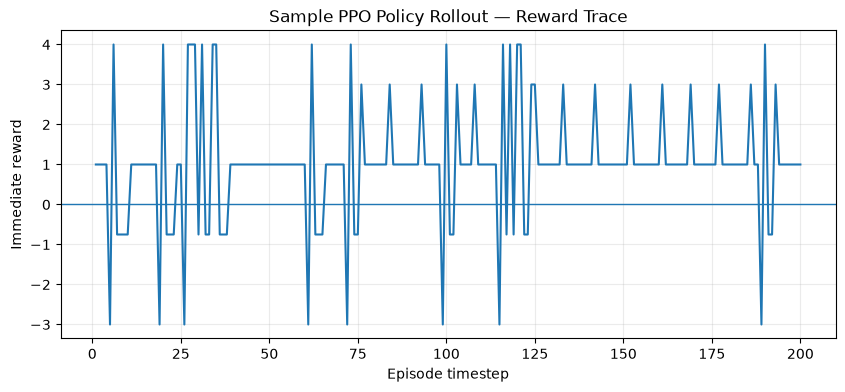

In [23]:
rollout_rewards = [
    row["reward"]
    for row in rollout_steps
]

plt.figure(figsize=(10, 4))
plt.plot(
    range(1, len(rollout_rewards) + 1),
    rollout_rewards,
)
plt.axhline(0, linewidth=1)
plt.xlabel("Episode timestep")
plt.ylabel("Immediate reward")
plt.title("Sample PPO Policy Rollout — Reward Trace")
plt.grid(alpha=0.25)
plt.show()


## Evaluation summary

After running the training and evaluation cells, record the numerical findings from the outputs above in `W02_RL_Analysis_Memo.md`.

The analysis should address:

- whether PPO converged during training;
- PPO mean ± standard deviation on the 20 held-out episodes;
- random-policy mean ± standard deviation;
- rule-based-policy mean ± standard deviation;
- whether PPO meaningfully outperformed each baseline;
- whether the learned policy behaved as expected from the reward design;
- any reward-hacking or failure behavior observed;
- what additional complexity a real Aido Rover deployment would introduce.

The numerical results should come from this notebook rather than being filled in before training.
